# **<div align="center">EDA FOR BINANCE COIN</div>**

EDA focused on two objectives: **short-, medium-, and long-term price prediction**, and **trend-change analysis** using slope.

In [78]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.analysis.eda import (
    split_train_test, time_plots, matrix_correlation, scatter_matrix,
    decompose_time_series, returns_and_volatility, trend_slope,
    moving_averages, autocorrelation_plots
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Initial Configuration**

In [79]:
CRYPTO_NAME = "usd-coin"
DATA_PATH = f"../data/processed/{CRYPTO_NAME}.csv"

## **Import dataset**

In [80]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date", drop=False).sort_index()

print(f"Observations: {len(df)}")
print(f"Period: {df.index.min().date()} -> {df.index.max().date()}")
display(df.head())
display(df.isna().sum())

Observations: 280
Period: 2025-02-06 -> 2025-11-12


,cryptocurrency_id,price_usd,market_cap,volume,date
date,,,,,
2025-02-06,5.0,1.00000,5.554900e+10,1.122790e+10,2025-02-06
2025-02-07,5.0,0.99999,5.574810e+10,1.090440e+10,2025-02-07
2025-02-08,5.0,0.99999,5.574810e+10,1.090440e+10,2025-02-08
2025-02-09,5.0,0.99999,5.574810e+10,1.090440e+10,2025-02-09
2025-02-10,5.0,0.99995,5.627930e+10,8.631850e+09,2025-02-10


cryptocurrency_id    0
price_usd            0
market_cap           0
volume               0
date                 0
dtype: int64

## **Train / Test split**

In [81]:
train, test = split_train_test(df, 0.8)
print(f"Train: {len(train)} observations")
print(f"Test: {len(test)} observations")
print(f"Train ends: {train.index.max().date()}")
print(f"Test starts: {test.index.min().date()}")

Train: 224 observations
Test: 56 observations
Train ends: 2025-09-17
Test starts: 2025-09-18


## **1. Price and market variables**
We analyze the temporal evolution and relationships between price, market cap, and volume.

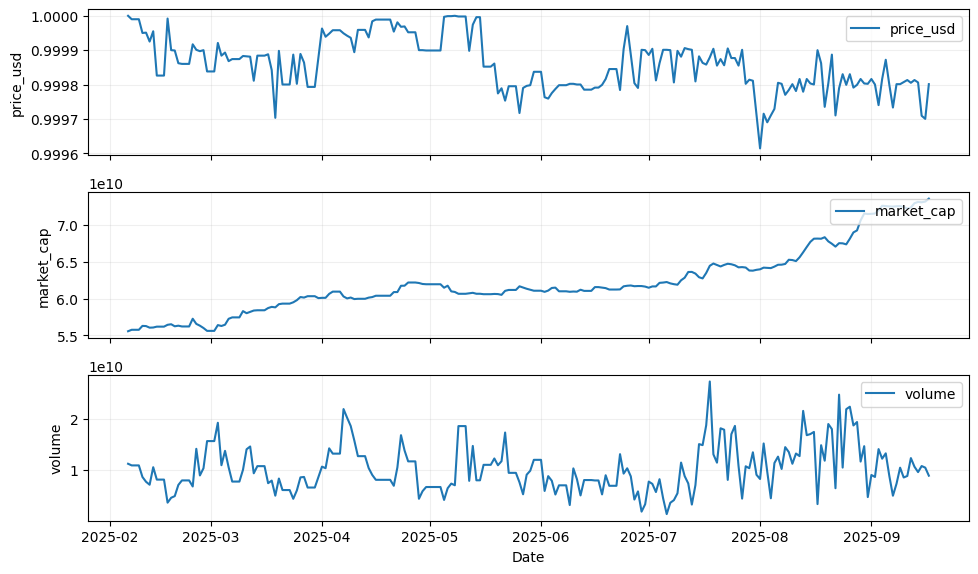

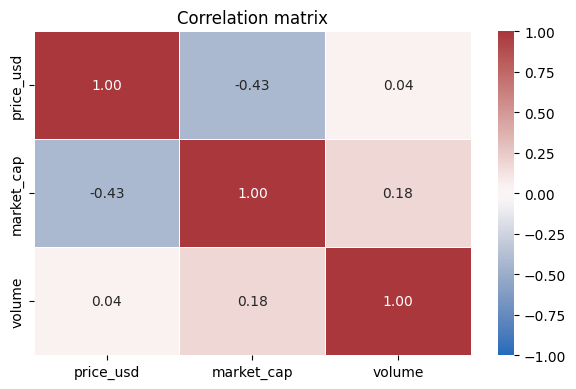

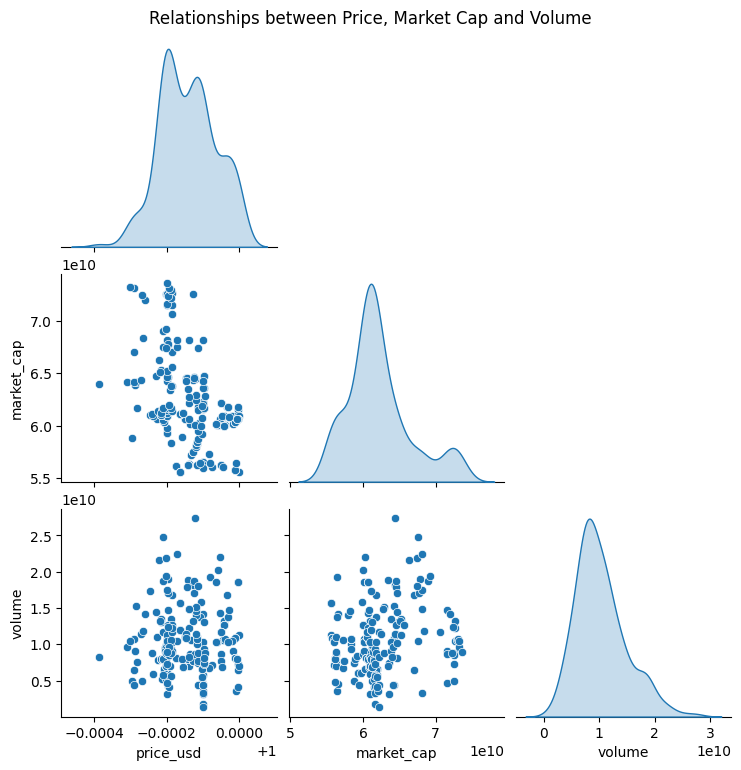

In [82]:
FEATURES = ["price_usd", "market_cap", "volume"]
time_plots(train, FEATURES)
matrix_correlation(train, FEATURES)
scatter_matrix(train, FEATURES)

## **2. Returns and volatility**
Returns and volatility help us study price behavior and possible regime changes.

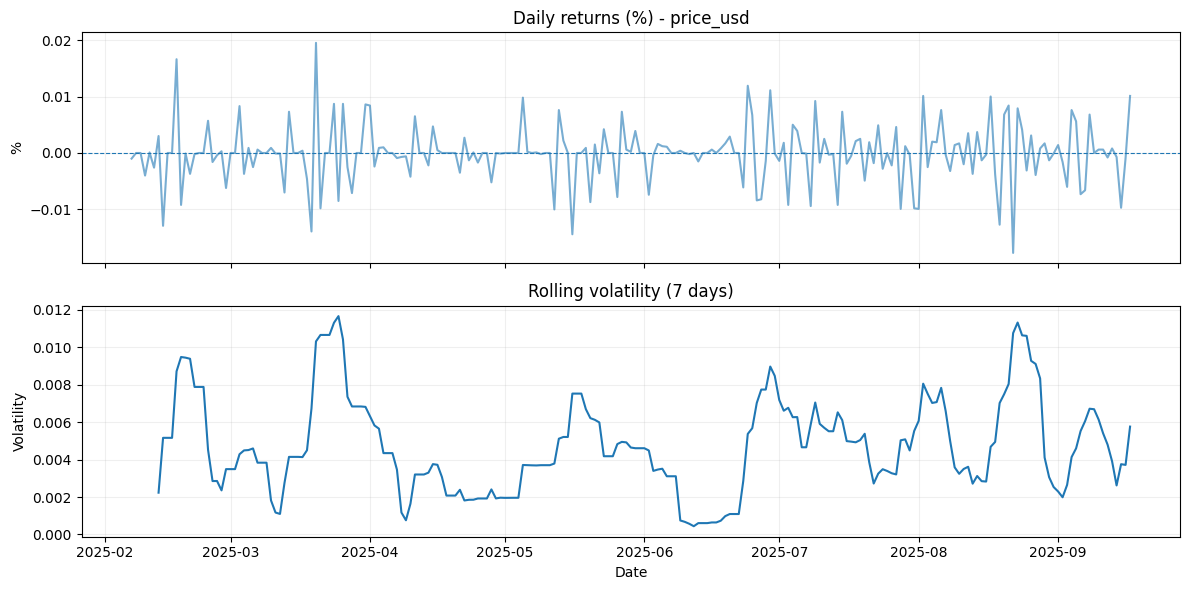

In [83]:
df_returns = returns_and_volatility(train, "price_usd", 7)

## **3. Autocorrelation**

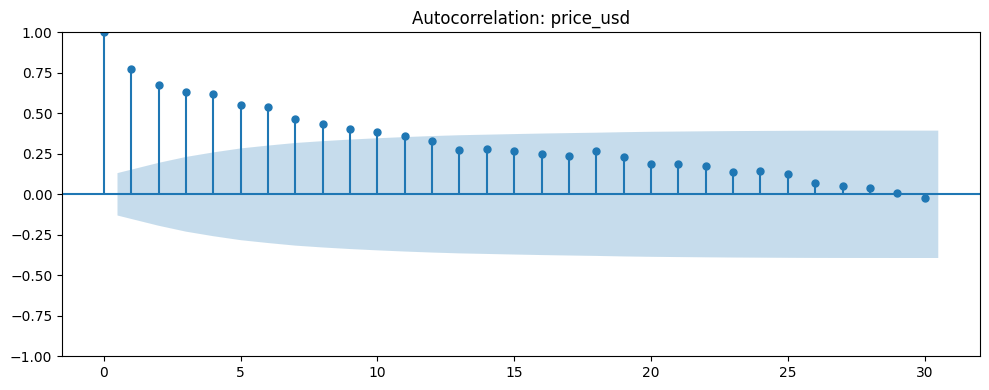

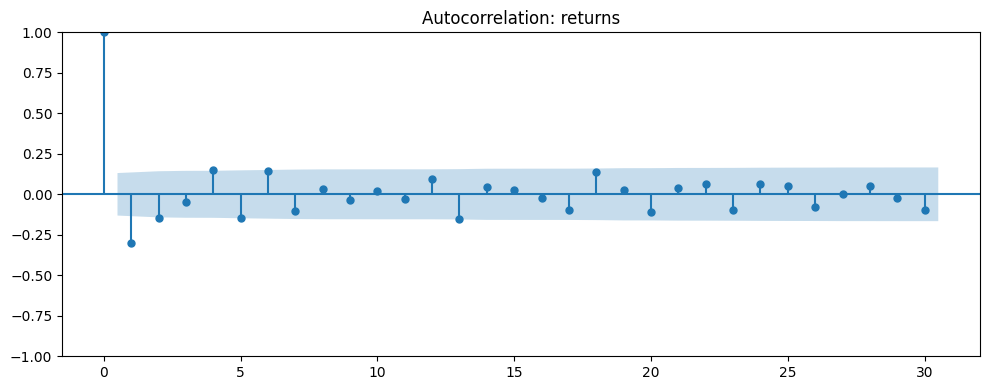

In [84]:
autocorrelation_plots(df_returns, ["price_usd", "returns"], lags=30)

## **4. Trend analysis**
We study the trend slope over 7-, 14-, and 30-day windows. We do not define categories or thresholds yet.

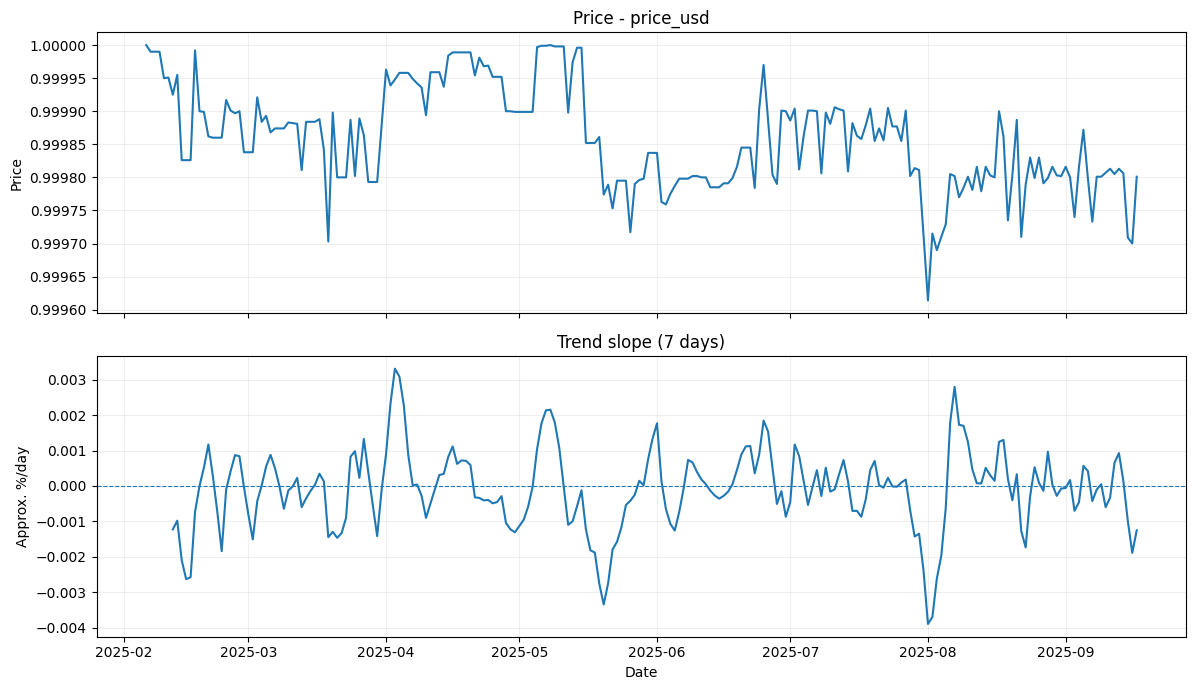

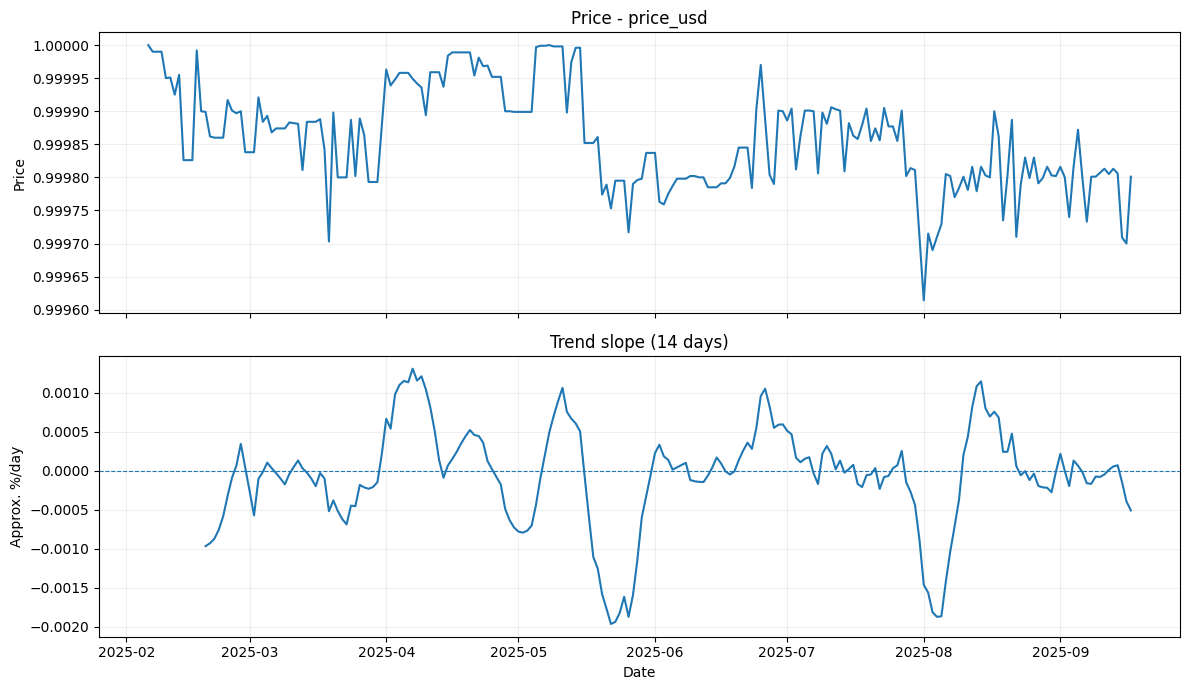

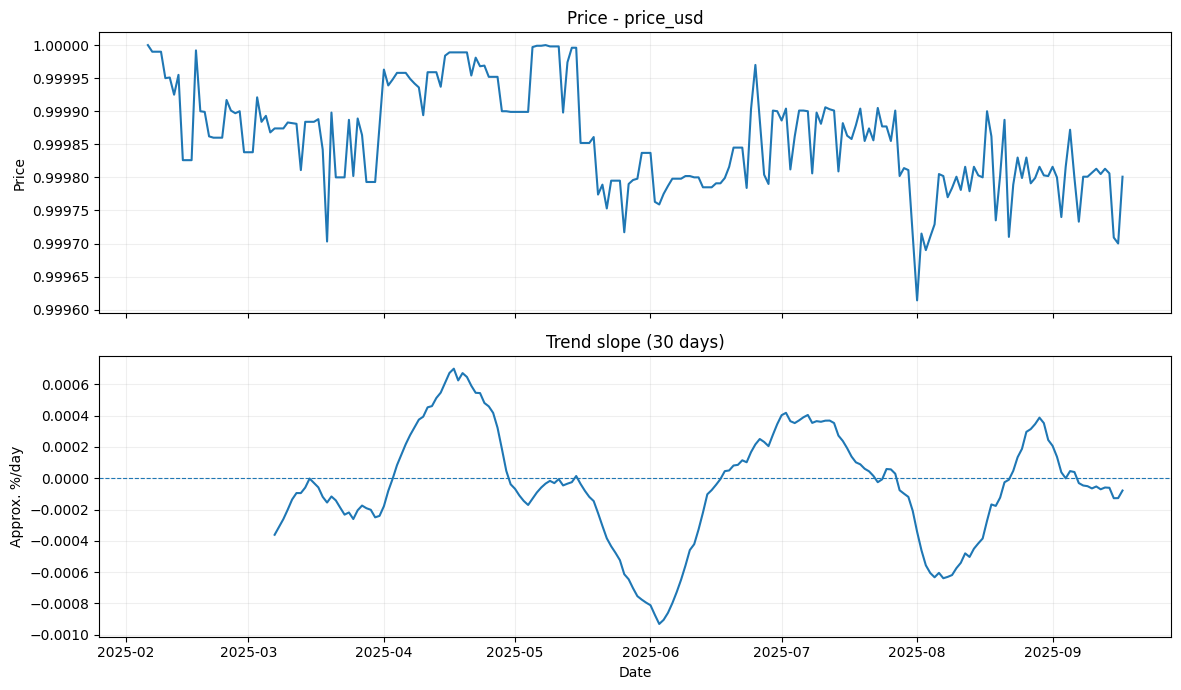

In [85]:
df_slope_7 = trend_slope(train, "price_usd", window=7)
df_slope_14 = trend_slope(train, "price_usd", window=14)
df_slope_30 = trend_slope(train, "price_usd", window=30)

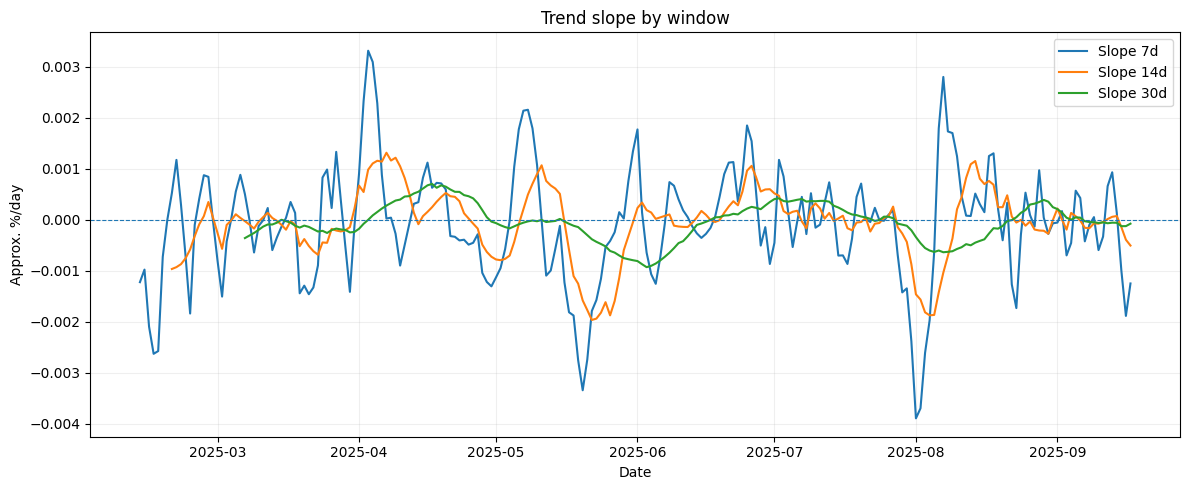

In [86]:
plt.figure(figsize=(12, 5))
for data, window in [(df_slope_7, 7), (df_slope_14, 14), (df_slope_30, 30)]:
    plt.plot(data.index, data["trend_slope_pct"], label=f"Slope {window}d")
plt.axhline(0, linewidth=0.8, linestyle="--")
plt.title("Trend slope by window")
plt.xlabel("Date")
plt.ylabel("Approx. %/day")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

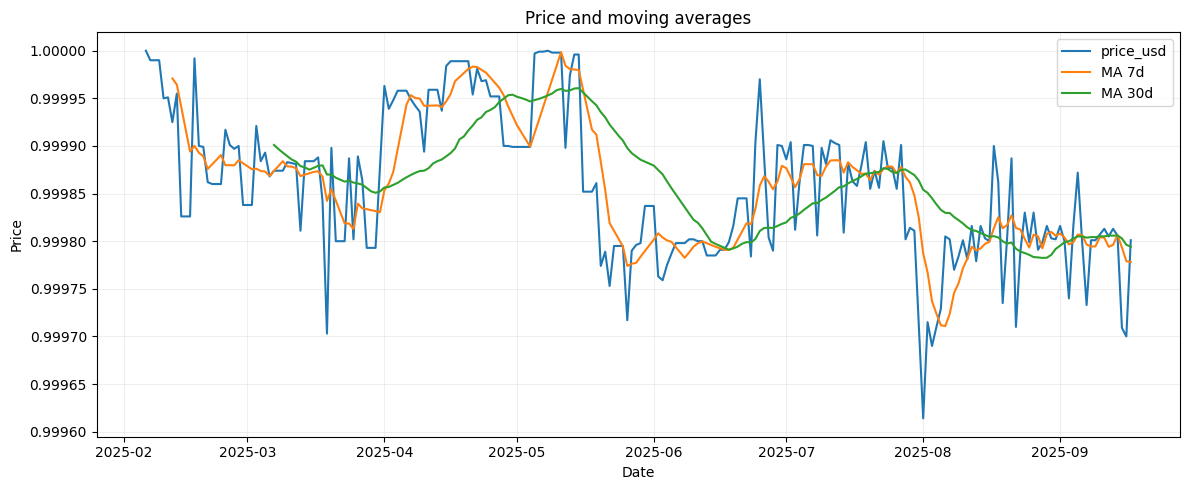

,cryptocurrency_id,price_usd,market_cap,volume,date,ma_7d,ma_30d
date,,,,,,,
2025-02-06,5.0,1.000000,5.554900e+10,1.122790e+10,2025-02-06,NaN,NaN
2025-02-07,5.0,0.999990,5.574810e+10,1.090440e+10,2025-02-07,NaN,NaN
2025-02-08,5.0,0.999990,5.574810e+10,1.090440e+10,2025-02-08,NaN,NaN
2025-02-09,5.0,0.999990,5.574810e+10,1.090440e+10,2025-02-09,NaN,NaN
2025-02-10,5.0,0.999950,5.627930e+10,8.631850e+09,2025-02-10,NaN,NaN
...,...,...,...,...,...,...,...
2025-09-13,5.0,0.999813,7.299120e+10,1.064740e+10,2025-09-13,0.999796,0.999806
2025-09-14,5.0,0.999806,7.316170e+10,9.589740e+09,2025-09-14,0.999807,0.999806
2025-09-15,5.0,0.999709,7.311470e+10,1.077860e+10,2025-09-15,0.999793,0.999803


In [87]:
moving_averages(train, "price_usd", windows=(7, 30))

## **5. Decomposition**
Decomposition is kept as exploratory analysis. We do not assume that 7 or 30 days is the correct period without comparing the results.

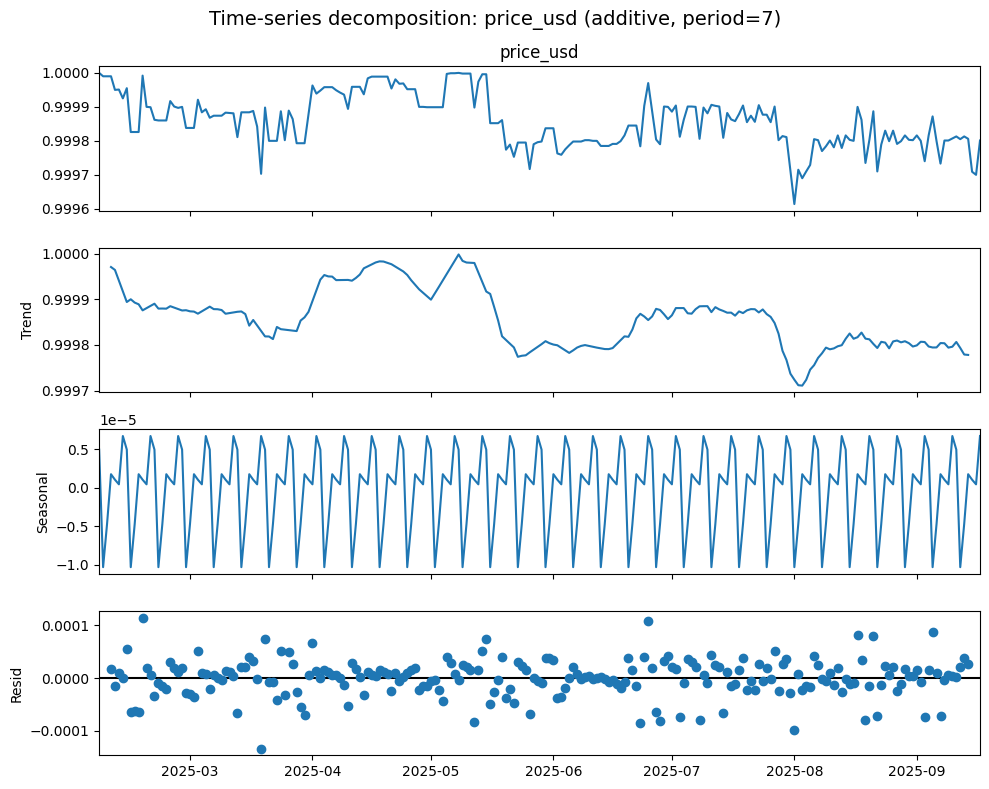

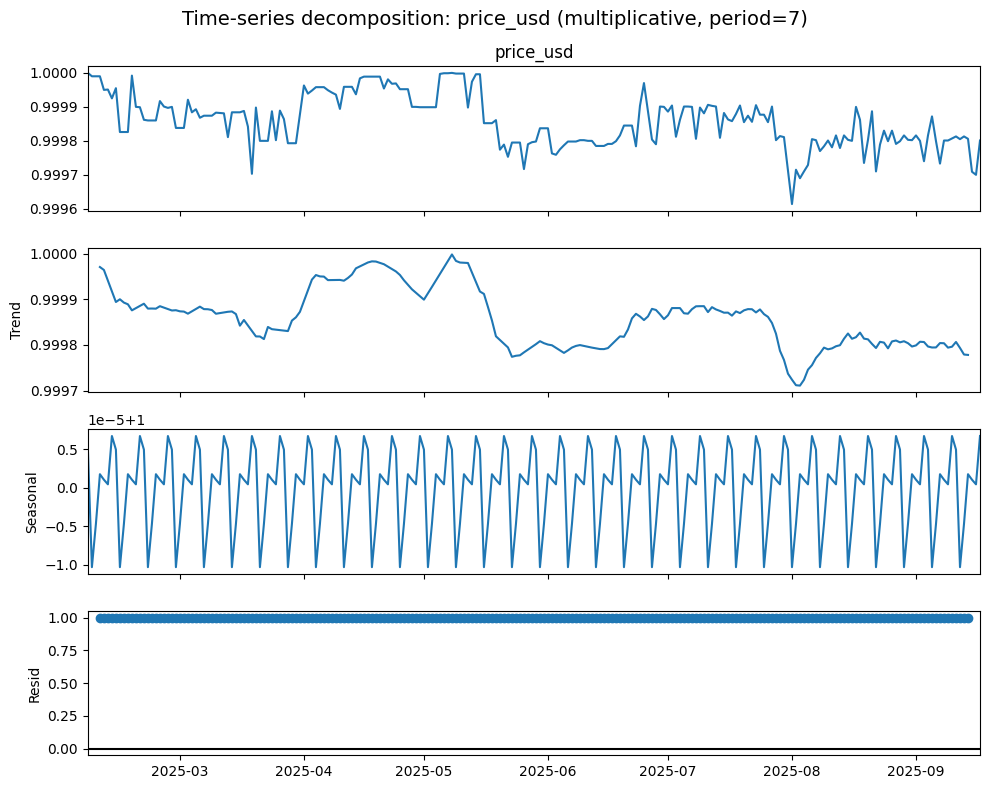

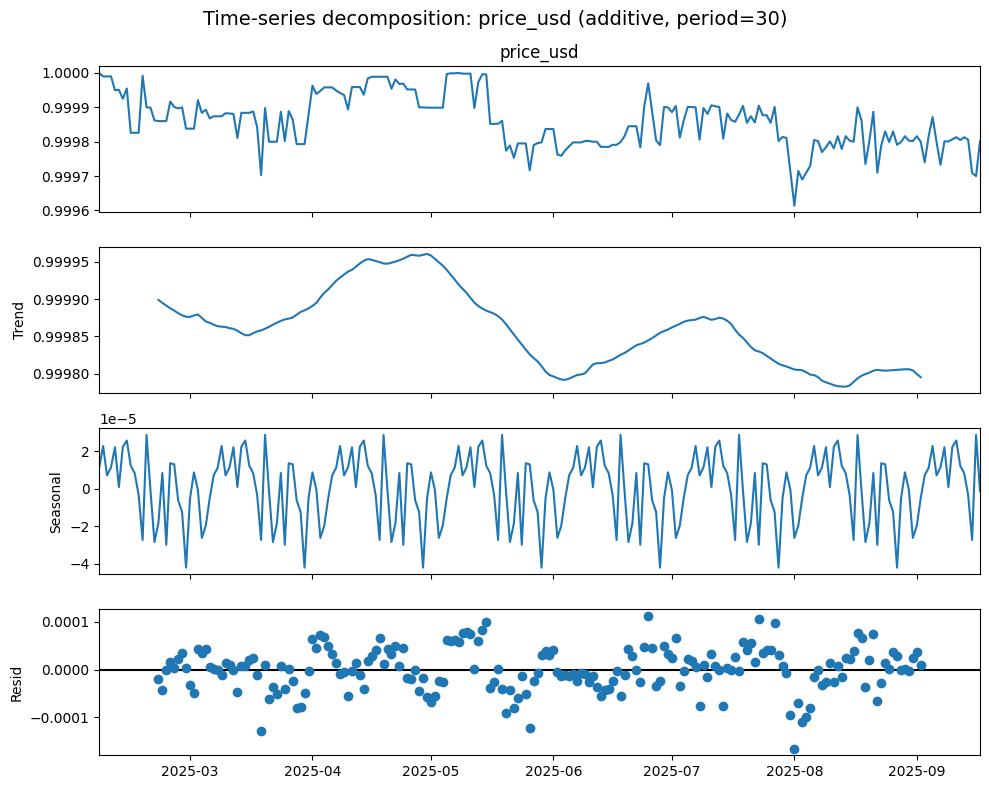

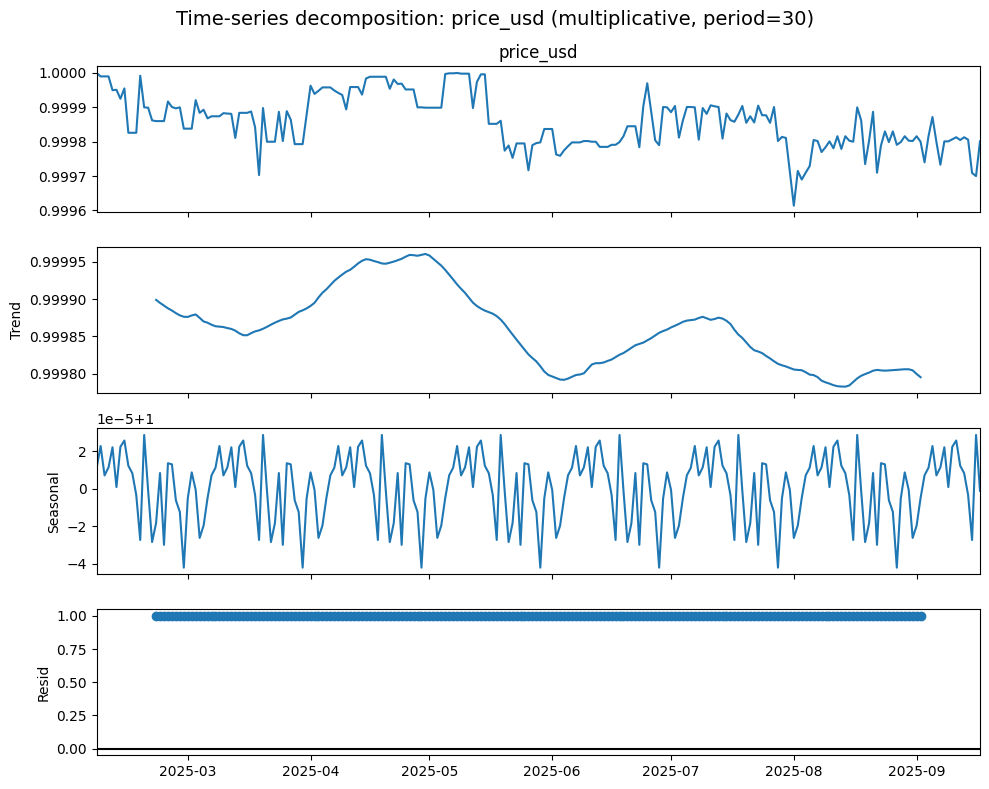

In [88]:
decompose_time_series(train, "price_usd", model="additive", freq=7)
decompose_time_series(train, "price_usd", model="multiplicative", freq=7)
decompose_time_series(train, "price_usd", model="additive", freq=30)
decompose_time_series(train, "price_usd", model="multiplicative", freq=30)

## **6. Conclusions / next step**
First, we will examine the distribution and stability of the slopes before defining categories such as strong decrease, decrease, stable, increase, and strong increase.

The short-, medium-, and long-term price-prediction horizons will be defined according to the actual frequency and length of the time series.